In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the chess dataset
df = pd.read_csv("games.csv")

In [5]:
print("--- Initial Data Inspection ---")
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nShape of the dataset (rows, columns):")
print(df.shape)

print("\nData types of each column:")
print(df.dtypes)

print("\nDetailed information about the dataset:")
df.info() # Use df.info() for a more comprehensive overview

--- Initial Data Inspection ---

First 5 rows of the dataset:
         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   



In [6]:
print("\n--- Descriptive Statistics ---")
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


--- Descriptive Statistics ---

Descriptive statistics for numerical columns:
         created_at  last_move_at         turns  white_rating  black_rating  \
count  2.005800e+04  2.005800e+04  20058.000000  20058.000000  20058.000000   
mean   1.483617e+12  1.483618e+12     60.465999   1596.631868   1588.831987   
std    2.850151e+10  2.850140e+10     33.570585    291.253376    291.036126   
min    1.376772e+12  1.376772e+12      1.000000    784.000000    789.000000   
25%    1.477548e+12  1.477548e+12     37.000000   1398.000000   1391.000000   
50%    1.496010e+12  1.496010e+12     55.000000   1567.000000   1562.000000   
75%    1.503170e+12  1.503170e+12     79.000000   1793.000000   1784.000000   
max    1.504493e+12  1.504494e+12    349.000000   2700.000000   2723.000000   

        opening_ply  
count  20058.000000  
mean       4.816981  
std        2.797152  
min        1.000000  
25%        3.000000  
50%        4.000000  
75%        6.000000  
max       28.000000  


In [7]:
print("\n--- Categorical Data Analysis ---")
print("\nValue counts for 'winner':")
print(df['winner'].value_counts())

print("\nValue counts for 'victory_status':")
print(df['victory_status'].value_counts())


--- Categorical Data Analysis ---

Value counts for 'winner':
winner
white    10001
black     9107
draw       950
Name: count, dtype: int64

Value counts for 'victory_status':
victory_status
resign       11147
mate          6325
outoftime     1680
draw           906
Name: count, dtype: int64



--- Visualizations ---


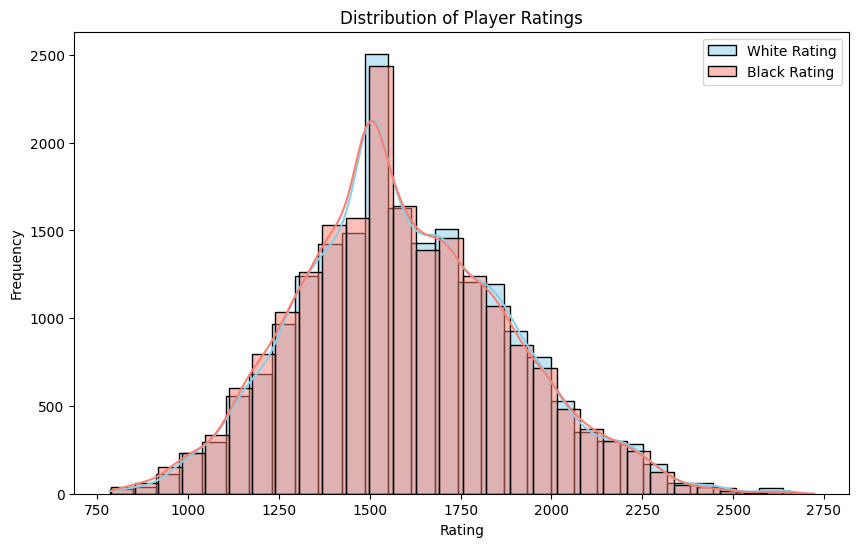

In [8]:
print("\n--- Visualizations ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['white_rating'], bins=30, kde=True, color='skyblue', label='White Rating')
sns.histplot(df['black_rating'], bins=30, kde=True, color='salmon', label='Black Rating')
plt.title('Distribution of Player Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.legend()
plt.show()

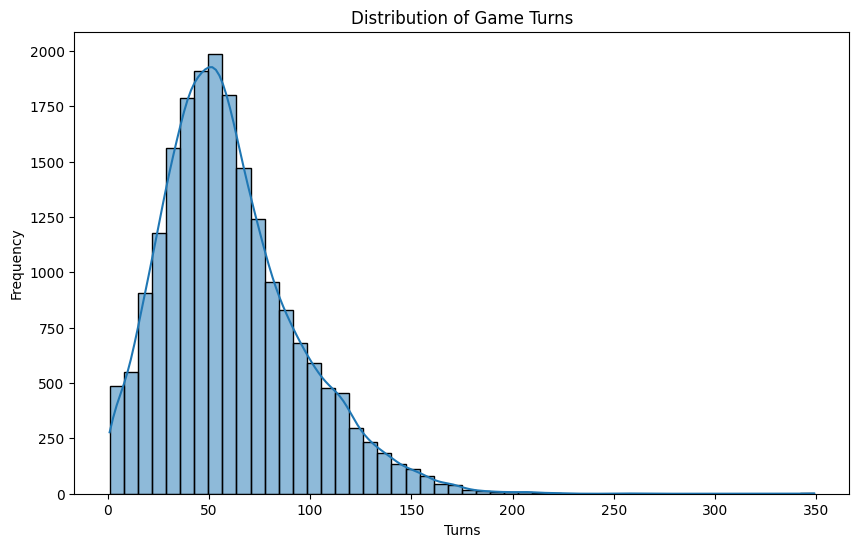

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['turns'], bins=50, kde=True)
plt.title('Distribution of Game Turns')
plt.xlabel('Turns')
plt.ylabel('Frequency')
plt.show()

In [10]:
# Let's analyze average ratings by winner
winner_avg_ratings = df.groupby('winner')[['white_rating', 'black_rating']].mean().reset_index()
print("\nAverage White and Black Ratings by Winner:")
print(winner_avg_ratings)


Average White and Black Ratings by Winner:
  winner  white_rating  black_rating
0  black   1549.246184   1638.227298
1   draw   1655.558947   1641.210526
2  white   1634.184182   1538.876712


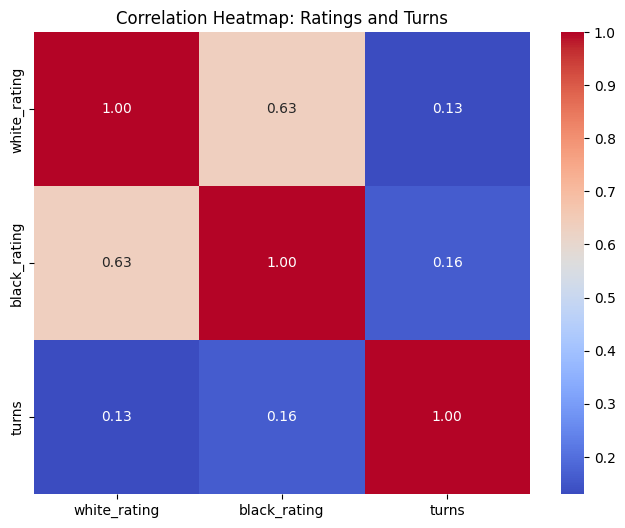

In [11]:
# Correlation Heatmap for relevant numerical columns
numerical_cols = ['white_rating', 'black_rating', 'turns']
corr = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Ratings and Turns")
plt.show()

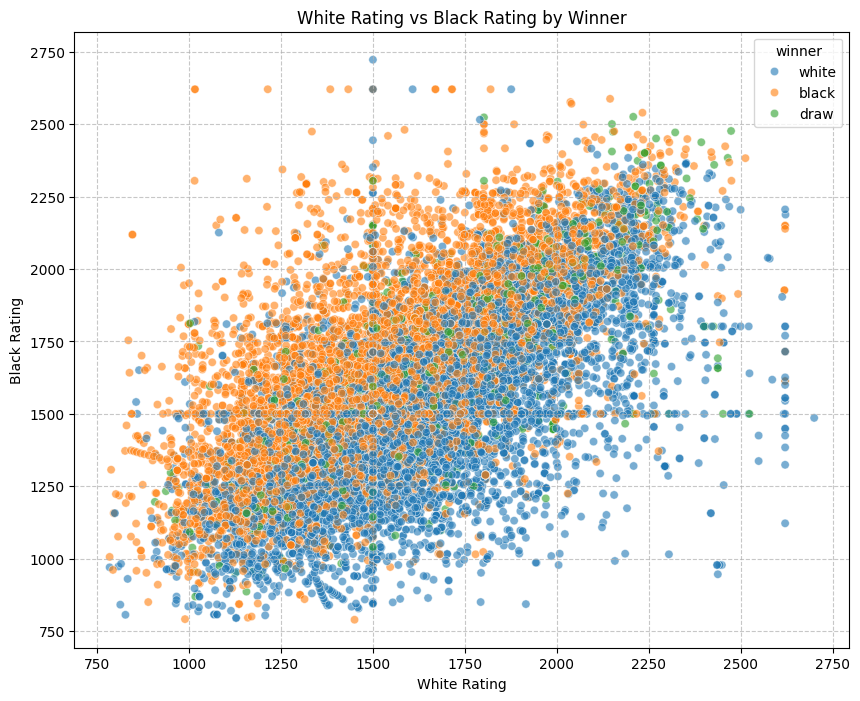

In [12]:
# Scatter plot of White Rating vs Black Rating
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='white_rating', y='black_rating', hue='winner', alpha=0.6)
plt.title('White Rating vs Black Rating by Winner')
plt.xlabel('White Rating')
plt.ylabel('Black Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Top 10 most frequent openings
top_openings = df['opening_name'].value_counts().head(10)
print("\nTop 10 Most Frequent Openings:")
print(top_openings)


Top 10 Most Frequent Openings:
opening_name
Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
French Defense: Knight Variation                 271
Scotch Game                                      271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Name: count, dtype: int64


/tmp/ipykernel_819/2300216605.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_openings.values, y=top_openings.index, palette='viridis')


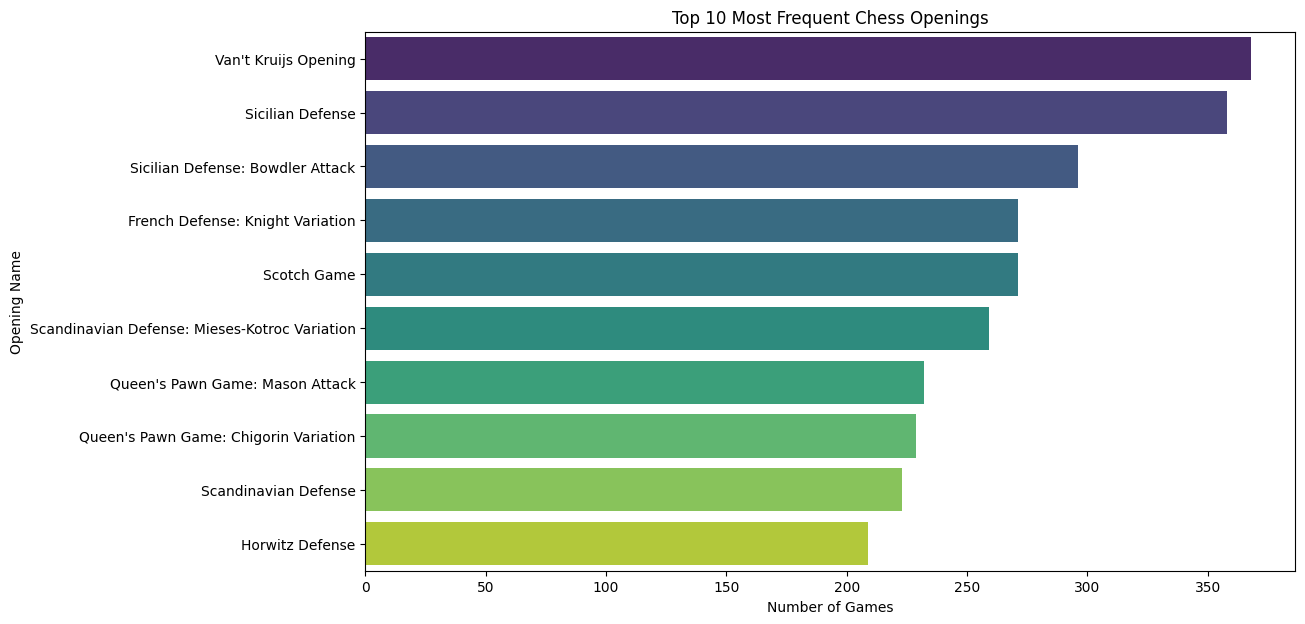

In [14]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_openings.values, y=top_openings.index, palette='viridis')
plt.title('Top 10 Most Frequent Chess Openings')
plt.xlabel('Number of Games')
plt.ylabel('Opening Name')
plt.show()